# Giai đoạn 7 — Giải thích mô hình (bản hoàn thiện)

Một mô hình chính xác nhưng "hộp đen" thì khó tin dùng trong bài toán an toàn. Câu hỏi: **mô hình dựa vào biến nào để quyết định?**

Ý tưởng đặc sắc: đo tầm quan trọng của biến bằng **hai phương pháp hoàn toàn độc lập** rồi đối chiếu (tam giác hóa):

1. **Permutation importance** trên mô hình cây — xáo trộn một biến, đo độ tụt hiệu năng.
2. **Trọng số DE** trên k-NN — thuật toán tiến hóa tự tìm biến nào cần nhân trọng số lớn.

Hai cách khác hẳn về bản chất; nếu **cùng kết luận** thì độ tin cậy được củng cố mạnh.

> **Sửa quan trọng so với bản trước.** Bản cũ đo trên *một lần chia* → rất nhiễu, nhất là khi H và S sát nút (dễ lật thứ tự). Bản này **trung bình qua cross-validation, báo cáo ± độ lệch và kiểm tra độ ổn định thứ tự**, cho **cả hai nhiệm vụ** (phát hiện & phân loại). Nhờ đó kết luận trung thực: *biến nào thực sự vững, biến nào chỉ là thứ yếu và thứ tự không chắc.*

## 1. Chuẩn bị

Hai phương pháp, giải thích đơn giản:
- **Permutation importance:** trộn ngẫu nhiên cột V → nếu accuracy tụt mạnh thì V quan trọng. Làm cho từng biến.
- **Trọng số DE:** k-NN nhân mỗi biến với một trọng số [0,1]; DE tìm bộ trọng số cho accuracy cao nhất (tối ưu **trên validation**, không đụng test). Trọng số lớn = biến quan trọng.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from collections import Counter
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from scipy.optimize import differential_evolution
import os

RANDOM_STATE = 42
FEATURES = ["V", "H", "S"]
os.makedirs("../result/figures", exist_ok=True)

try:
    import shap; HAS_SHAP = True
except Exception:
    HAS_SHAP = False
print("SHAP:", "có (dùng làm minh họa thêm)" if HAS_SHAP else "không có (bỏ qua phần minh họa SHAP)")

try:
    df = pd.read_excel("../Data/Mine_Dataset_main.xls", engine="xlrd")
except Exception:
    df = pd.read_excel("../Data/Mine_Dataset_main.xls")
df.columns = [str(c).strip() for c in df.columns]
if list(df.columns[:4]) != ["V","H","S","M"]:
    df = df.rename(columns=dict(zip(df.columns[:4], ["V","H","S","M"])))
df["M"] = df["M"].astype(int)
X = df[FEATURES].values.astype(float)
y_class  = df["M"].values
y_detect = (df["M"] != 1).astype(int).values
print("Đã nạp:", df.shape)

SHAP: có (dùng làm minh họa thêm)
Đã nạp: (338, 4)


## 2. Đo tầm quan trọng — trung bình qua cross-validation

Với mỗi fold: fit mô hình cây trên train → permutation importance trên test; và tối ưu trọng số DE trên validation. Lặp nhiều fold, lấy **trung bình ± độ lệch** và kiểm tra **thứ tự có ổn định qua các fold không**.

*(Chạy vài phút do DE × nhiều fold × 2 nhiệm vụ.)*

In [2]:
def de_weights(Xa, ya, Xb, yb, k=4):
    f = lambda w: -accuracy_score(yb, KNeighborsClassifier(k).fit(Xa*w, ya).predict(Xb*w))
    return differential_evolution(f, [(0,1)]*Xa.shape[1], maxiter=20, popsize=8,
                                  seed=RANDOM_STATE, tol=1e-3, polish=False).x

def importance_cv(X, y, n_splits=5, n_repeats=3):
    perm, dew = [], []
    for rep in range(n_repeats):
        skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE+rep)
        for tr, te in skf.split(X, y):
            Xtr, Xte, ytr, yte = X[tr], X[te], y[tr], y[te]
            s = StandardScaler().fit(Xtr); Xtr2, Xte2 = s.transform(Xtr), s.transform(Xte)
            mdl = HistGradientBoostingClassifier(random_state=RANDOM_STATE).fit(Xtr2, ytr)
            pi = permutation_importance(mdl, Xte2, yte, n_repeats=10,
                                        random_state=RANDOM_STATE).importances_mean
            pi = np.clip(pi, 0, None); perm.append(pi/pi.sum() if pi.sum()>0 else np.zeros_like(pi))
            Xit, Xiv, yit, yiv = train_test_split(Xtr2, ytr, test_size=0.25,
                                                  stratify=ytr, random_state=RANDOM_STATE)
            w = de_weights(Xit, yit, Xiv, yiv); dew.append(w/w.sum())
    return np.array(perm)*100, np.array(dew)*100

def order_stability(mat):
    orders = [tuple(np.argsort(-row)) for row in mat]
    common, cnt = Counter(orders).most_common(1)[0]
    return [FEATURES[i] for i in common], cnt/len(orders)

results = {}
for task, y in [("Phân loại", y_class), ("Phát hiện", y_detect)]:
    print(f"Đang chạy: {task}...")
    perm, dew = importance_cv(X, y)
    results[task] = (perm, dew)
print("Xong.")

Đang chạy: Phân loại...
Đang chạy: Phát hiện...
Xong.


## 3. Bảng tầm quan trọng (trung bình ± độ lệch, %)

In [3]:
for task, (perm, dew) in results.items():
    print(f"### {task}")
    tbl = pd.DataFrame({
        "Biến": FEATURES,
        "Permutation (%)": [f"{perm[:,i].mean():.1f} ± {perm[:,i].std():.1f}" for i in range(3)],
        "Trọng số DE (%)": [f"{dew[:,i].mean():.1f} ± {dew[:,i].std():.1f}" for i in range(3)],
    })
    print(tbl.to_string(index=False))
    o1, s1 = order_stability(perm); o2, s2 = order_stability(dew)
    print(f"  Thứ tự Permutation: {' > '.join(o1)}  (ổn định {s1*100:.0f}% fold)")
    print(f"  Thứ tự DE:          {' > '.join(o2)}  (ổn định {s2*100:.0f}% fold)")
    print()

### Phân loại
Biến Permutation (%) Trọng số DE (%)
   V      69.3 ± 6.8     64.1 ± 11.1
   H      16.4 ± 5.7      10.3 ± 3.9
   S      14.4 ± 3.5      25.6 ± 9.2
  Thứ tự Permutation: V > H > S  (ổn định 80% fold)
  Thứ tự DE:          V > S > H  (ổn định 93% fold)

### Phát hiện
Biến Permutation (%) Trọng số DE (%)
   V      67.5 ± 9.7     57.1 ± 19.7
   H      18.7 ± 5.7       7.5 ± 6.7
   S      13.8 ± 5.7     35.4 ± 23.2
  Thứ tự Permutation: V > H > S  (ổn định 80% fold)
  Thứ tự DE:          S > V > H  (ổn định 40% fold)



## 4. Biểu đồ đối chiếu hai phương pháp (cả hai nhiệm vụ)

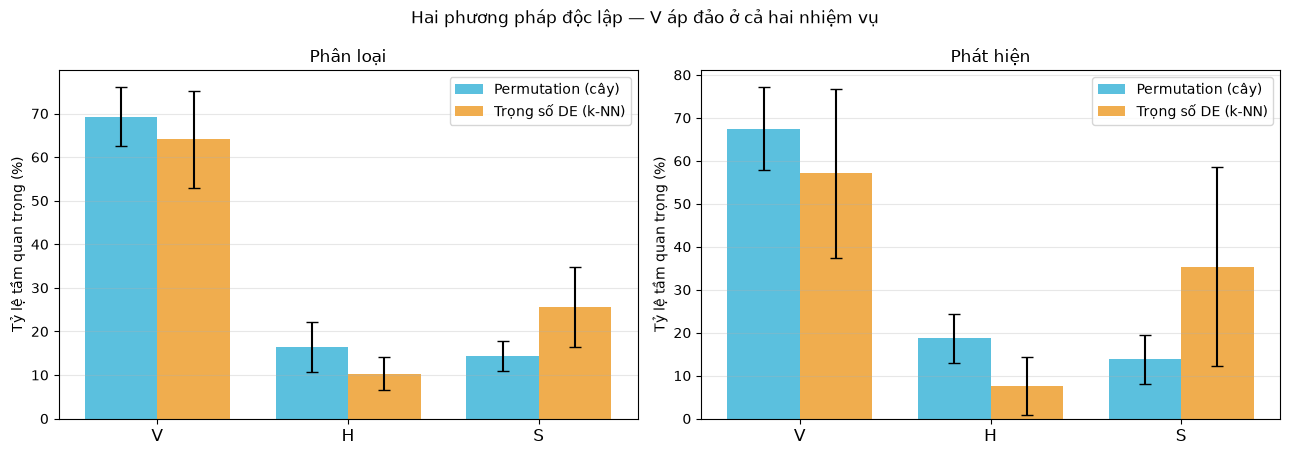

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
for ax, (task, (perm, dew)) in zip(axes, results.items()):
    x = np.arange(3); wbar = 0.38
    ax.bar(x-wbar/2, perm.mean(0), wbar, yerr=perm.std(0), capsize=4,
           label="Permutation (cây)", color="#5bc0de")
    ax.bar(x+wbar/2, dew.mean(0),  wbar, yerr=dew.std(0),  capsize=4,
           label="Trọng số DE (k-NN)", color="#f0ad4e")
    ax.set_xticks(x); ax.set_xticklabels(FEATURES, fontsize=12)
    ax.set_ylabel("Tỷ lệ tầm quan trọng (%)"); ax.set_title(f"{task}")
    ax.legend(); ax.grid(axis="y", alpha=0.3)
fig.suptitle("Hai phương pháp độc lập — V áp đảo ở cả hai nhiệm vụ", fontsize=12)
plt.tight_layout(); plt.savefig("../result/figures/07_tam_quan_trong.png", bbox_inches="tight"); plt.show()

## 5. Kết luận đọc từ số liệu (tự động, trung thực)

Ô dưới tự viết kết luận dựa trên **mức áp đảo của V** và **độ ổn định thứ tự H/S** — không khẳng định cứng nếu dữ liệu không cho phép.

In [5]:
for task, (perm, dew) in results.items():
    vp, vd = perm[:,0].mean(), dew[:,0].mean()
    o1, s1 = order_stability(perm); o2, s2 = order_stability(dew)
    hs_perm = "H > S" if perm[:,1].mean() > perm[:,2].mean() else "S > H"
    hs_de   = "H > S" if dew[:,1].mean() > dew[:,2].mean() else "S > H"
    agree = (o1 == o2)
    print(f"### {task}")
    print(f"  • V là biến áp đảo: {vp:.0f}% (permutation), {vd:.0f}% (DE) — cả hai phương pháp đồng thuận.")
    if agree and s1 >= 0.7 and s2 >= 0.7:
        print(f"  • Thứ tự đầy đủ {' > '.join(o1)} ỔN ĐỊNH và hai phương pháp khớp -> kết luận vững.")
    else:
        print(f"  • H và S đều THỨ YẾU; thứ tự giữa chúng KHÔNG bền: "
              f"permutation nói {hs_perm} (ổn định {s1*100:.0f}%), DE nói {hs_de} (ổn định {s2*100:.0f}%).")
        print(f"    -> Kết luận trung thực: chỉ khẳng định 'V quan trọng nhất', không khẳng định thứ tự H/S.")
    print()

### Phân loại
  • V là biến áp đảo: 69% (permutation), 64% (DE) — cả hai phương pháp đồng thuận.
  • H và S đều THỨ YẾU; thứ tự giữa chúng KHÔNG bền: permutation nói H > S (ổn định 80%), DE nói S > H (ổn định 93%).
    -> Kết luận trung thực: chỉ khẳng định 'V quan trọng nhất', không khẳng định thứ tự H/S.

### Phát hiện
  • V là biến áp đảo: 67% (permutation), 57% (DE) — cả hai phương pháp đồng thuận.
  • H và S đều THỨ YẾU; thứ tự giữa chúng KHÔNG bền: permutation nói H > S (ổn định 80%), DE nói S > H (ổn định 40%).
    -> Kết luận trung thực: chỉ khẳng định 'V quan trọng nhất', không khẳng định thứ tự H/S.



## 6. Minh họa SHAP (tùy chọn, nếu máy có `shap`)

SHAP phân bổ đóng góp từng biến theo lý thuyết trò chơi Shapley — cùng thông điệp với permutation importance nhưng hình đẹp hơn. Đây chỉ là **minh họa trên một lần fit**; con số định lượng vững nằm ở phần CV bên trên.

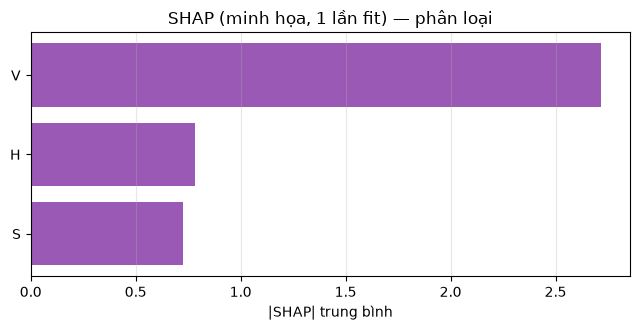

SHAP xác nhận cùng xu hướng: ['V', 'H', 'S']


In [6]:
if HAS_SHAP:
    import shap
    Xtr, Xte, ytr, yte = train_test_split(X, y_class, test_size=1/3,
                                          stratify=y_class, random_state=RANDOM_STATE)
    s = StandardScaler().fit(Xtr); Xtr2, Xte2 = s.transform(Xtr), s.transform(Xte)
    m = HistGradientBoostingClassifier(random_state=RANDOM_STATE).fit(Xtr2, ytr)
    try:
        expl = shap.TreeExplainer(m); sv = expl.shap_values(Xte2)
        arr = np.abs(np.array(sv))
        mean_abs = arr.mean(axis=tuple(i for i in range(arr.ndim) if i != arr.ndim-1)) \
                   if arr.ndim >= 2 else arr
        # chuẩn hóa an toàn về theo trục đặc trưng
        if mean_abs.shape[-1] != 3:
            mean_abs = np.abs(np.array(sv)).mean(axis=0)
            if mean_abs.ndim > 1: mean_abs = mean_abs.mean(axis=-1)
        mean_abs = np.ravel(mean_abs)[:3]
        plt.figure(figsize=(6.5,3.4))
        order = np.argsort(mean_abs)
        plt.barh([FEATURES[i] for i in order], mean_abs[order], color="#9b59b6")
        plt.xlabel("|SHAP| trung bình"); plt.title("SHAP (minh họa, 1 lần fit) — phân loại")
        plt.grid(axis="x", alpha=0.3); plt.tight_layout()
        plt.savefig("../result/figures/07_shap.png", bbox_inches="tight"); plt.show()
        print("SHAP xác nhận cùng xu hướng:", [FEATURES[i] for i in np.argsort(-mean_abs)])
    except Exception as e:
        print("SHAP không hỗ trợ mô hình này ở đây:", e, "-> bỏ qua, dùng kết quả permutation ở trên.")
else:
    print("Không có shap -> bỏ qua. Kết quả permutation importance ở trên đã đủ và vững hơn (có CV).")

## 7. Ý nghĩa vật lý & tổng kết

**Đọc kết quả (trung thực):**
- **V (điện áp dị thường)** là tín hiệu trực tiếp của vật thể kim loại → cả permutation importance lẫn trọng số DE, ở cả hai nhiệm vụ, đều cho V **áp đảo**. Đây là kết luận vững nhờ tam giác hóa hai phương pháp độc lập + lập luận vật lý.
- **H (độ cao)** và **S (loại đất)** là **thứ yếu**; thứ tự tương đối giữa chúng **không bền** (hai phương pháp có thể bất đồng, độ ổn định thấp) — nên không nên khẳng định "H > S" hay "S > H". Điều này cũng lý giải vì sao GĐ2 thấy trọng số của bài báo cho thứ tự H/S khác nhau giữa hai nhiệm vụ: đó là vùng nhiễu, không phải phát hiện thực.

**Cho báo cáo:**
- Nhấn mạnh đóng góp: đối chiếu **hai phương pháp giải thích độc lập** (chưa nghiên cứu nào làm trên bộ này), có **định lượng độ ổn định** thay vì kết luận từ một lần chạy.
- Thông điệp: mô hình học đúng bản chất vật lý (dựa vào V), không bắt tương quan giả; và trung thực về giới hạn (H/S không tách bạch được với dữ liệu hiện có).

Đến đây phần phân tích (GĐ 2–7) đã trọn vẹn. Giai đoạn 8 đóng gói mô hình thành sản phẩm chạy được.